In [2]:
import requests
import matplotlib.pyplot as plt
import seaborn as sns  
import pandas as pd
import numpy as np
import time
from bs4 import BeautifulSoup
from mpl_toolkits.mplot3d import Axes3D

sns.set(style="whitegrid")

In [3]:
years = [2021, 2022, 2023, 2024]
all_data = []

for year in years:
    print(f"Scraping season {year}...")
    
    url = f"https://www.basketball-reference.com/leagues/NBA_{year}_per_game.html"
    
    df = pd.read_html(url)[0]
    df = df[df["Rk"] != "Rk"]
    
    df = df[["Player", "Pos", "Age", "Team", "G", "PTS", "AST", "TRB"]]
    df["Season"] = year
    
    all_data.append(df)
    
    time.sleep(2)

final_df = pd.concat(all_data, ignore_index=True)

print("Jumlah data:", final_df.shape)
final_df.head(50)

Scraping season 2021...
Scraping season 2022...
Scraping season 2023...
Scraping season 2024...
Jumlah data: (2935, 9)


,Player,Pos,Age,Team,G,PTS,AST,TRB,Season
0,Stephen Curry,PG,32.0,GSW,63.0,32.0,5.8,5.5,2021
1,Bradley Beal,SG,27.0,WAS,60.0,31.3,4.4,4.7,2021
2,Damian Lillard,PG,30.0,POR,67.0,28.8,7.5,4.2,2021
3,Joel Embiid,C,26.0,PHI,51.0,28.5,2.8,10.6,2021
4,Giannis Antetokounmpo,PF,26.0,MIL,61.0,28.1,5.9,11.0,2021
5,Luka Dončić,PG,21.0,DAL,66.0,27.7,8.6,8.0,2021
6,Zach LaVine,SG,25.0,CHI,58.0,27.4,4.9,5.0,2021
7,Zion Williamson,PF,20.0,NOP,61.0,27.0,3.7,7.2,2021
8,Kevin Durant,PF,32.0,BRK,35.0,26.9,5.6,7.1,2021
9,Kyrie Irving,PG,28.0,BRK,54.0,26.9,6.0,4.8,2021


In [4]:
df = pd.read_html(url)[0]
print(df.columns)

Index(['Rk', 'Player', 'Age', 'Team', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA',
       'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA',
       'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS',
       'Awards'],
      dtype='object')


In [5]:
final_df = final_df[final_df["Team"] != "TOT"]

In [6]:
numeric_cols = ["Age", "G", "PTS", "AST", "TRB"]

for col in numeric_cols:
    final_df[col] = pd.to_numeric(final_df[col])

In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2935 entries, 0 to 2934
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  2935 non-null   object 
 1   Pos     2931 non-null   object 
 2   Age     2931 non-null   float64
 3   Team    2931 non-null   object 
 4   G       2931 non-null   float64
 5   PTS     2931 non-null   float64
 6   AST     2931 non-null   float64
 7   TRB     2931 non-null   float64
 8   Season  2935 non-null   int64  
dtypes: float64(5), int64(1), object(3)
memory usage: 206.5+ KB


: 

In [ ]:
plt.figure()
plt.hist(final_df["Age"], bins=15)
plt.title("Distribusi Umur Pemain NBA")
plt.xlabel("Age")
plt.ylabel("Jumlah Pemain")
plt.show()

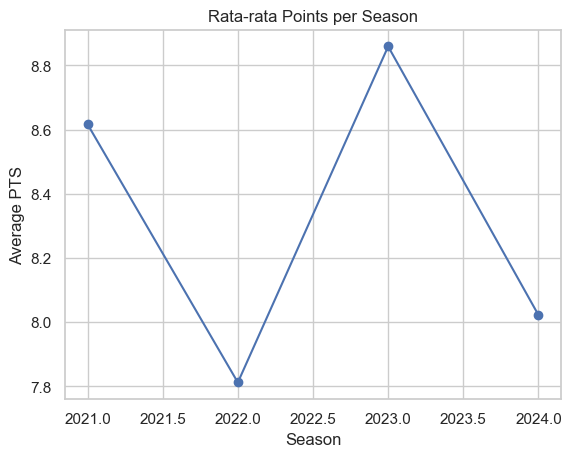

In [ ]:
avg_pts = final_df.groupby("Season")["PTS"].mean()

plt.figure()
plt.plot(avg_pts.index, avg_pts.values, marker="o")
plt.title("Rata-rata Points per Season")
plt.xlabel("Season")
plt.ylabel("Average PTS")
plt.show()

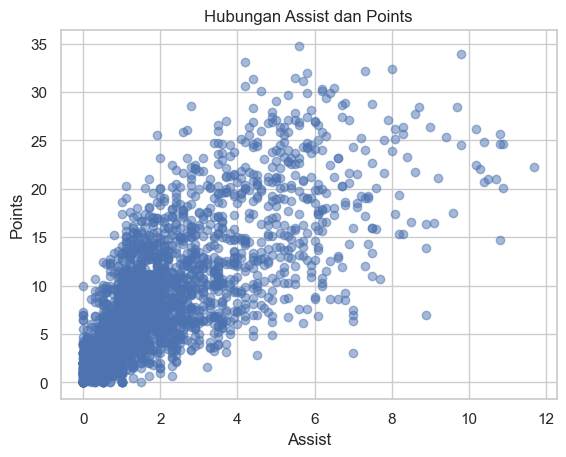

In [ ]:
plt.figure()
plt.scatter(final_df["AST"], final_df["PTS"], alpha=0.5)
plt.title("Hubungan Assist dan Points")
plt.xlabel("Assist")
plt.ylabel("Points")
plt.show()

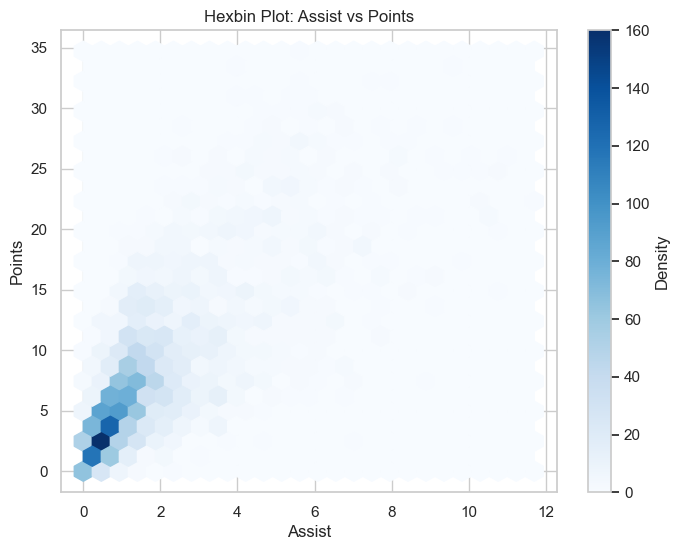

In [ ]:
plt.figure(figsize=(8,6))

plt.hexbin(
    final_df["AST"],
    final_df["PTS"],
    gridsize=25,
    cmap="Blues"
)

plt.colorbar(label="Density")
plt.xlabel("Assist")
plt.ylabel("Points")
plt.title("Hexbin Plot: Assist vs Points")

plt.show()

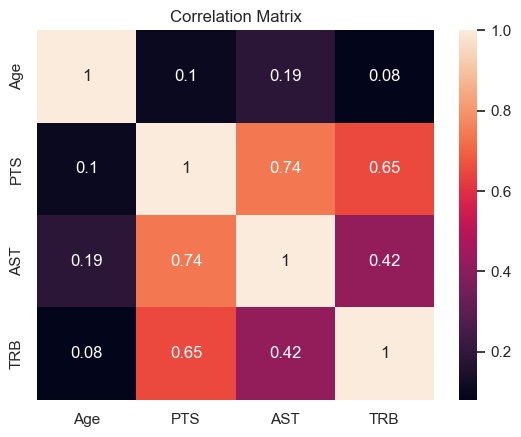

In [ ]:
corr = final_df[["Age", "PTS", "AST", "TRB"]].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

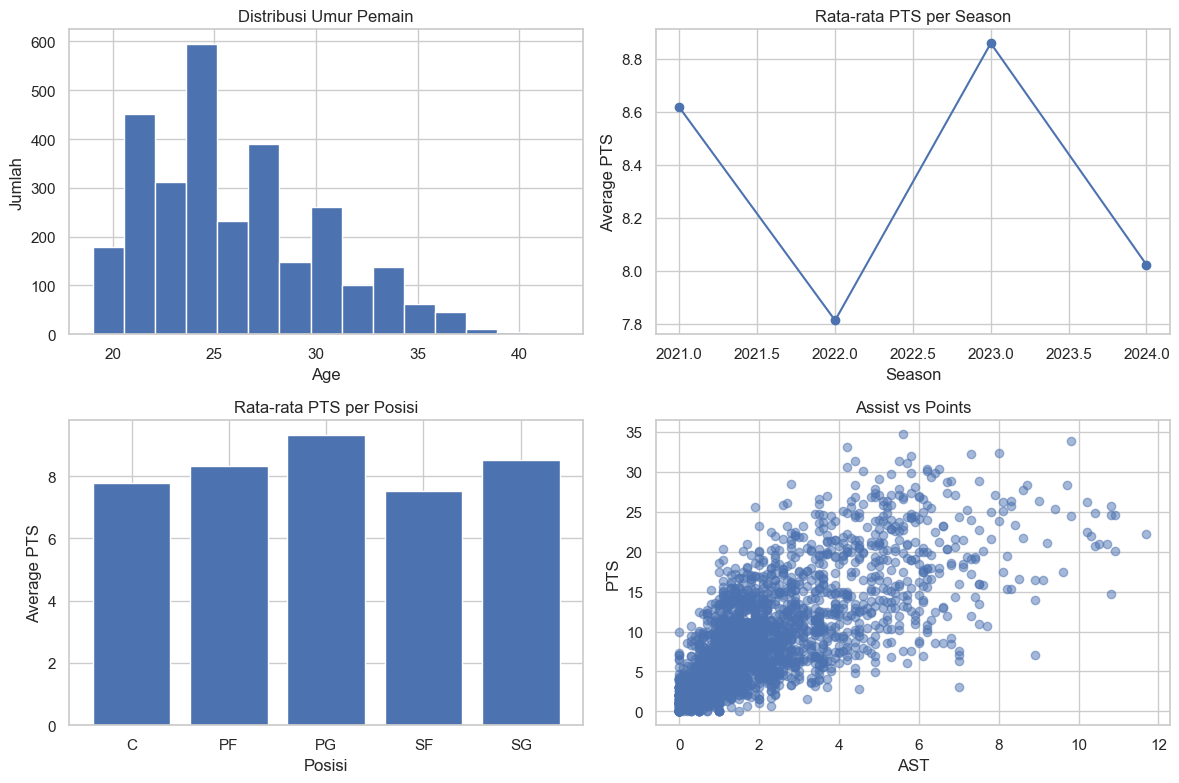

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Diagram Batang 1
axes[0, 0].hist(final_df["Age"], bins=15)
axes[0, 0].set_title("Distribusi Umur Pemain")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Jumlah")

# Diagram Garis
avg_pts = final_df.groupby("Season")["PTS"].mean()
axes[0, 1].plot(avg_pts.index, avg_pts.values, marker="o")
axes[0, 1].set_title("Rata-rata PTS per Season")
axes[0, 1].set_xlabel("Season")
axes[0, 1].set_ylabel("Average PTS")

# Diagram Batang 2
avg_pos = final_df.groupby("Pos")["PTS"].mean()
axes[1, 0].bar(avg_pos.index, avg_pos.values)
axes[1, 0].set_title("Rata-rata PTS per Posisi")
axes[1, 0].set_xlabel("Posisi")
axes[1, 0].set_ylabel("Average PTS")

# Diagram Scatter plot
axes[1, 1].scatter(final_df["AST"], final_df["PTS"], alpha=0.5)
axes[1, 1].set_title("Assist vs Points")
axes[1, 1].set_xlabel("AST")
axes[1, 1].set_ylabel("PTS")

plt.tight_layout()
plt.show()

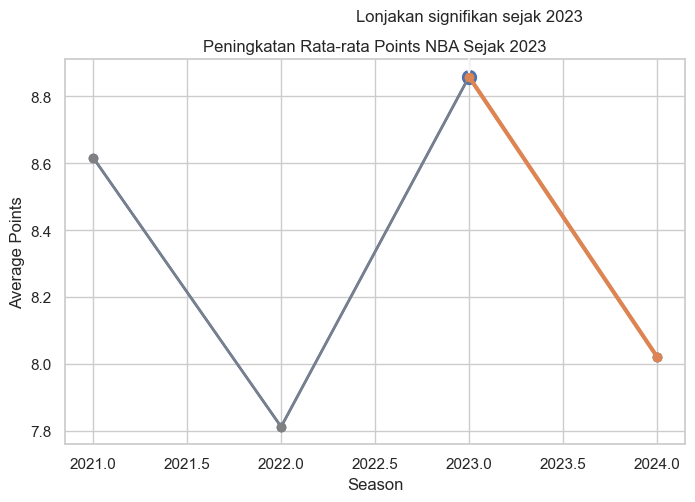

In [ ]:
# Hitung rata-rata PTS per season
avg_pts = final_df.groupby("Season")["PTS"].mean()

# Buat figure
plt.figure(figsize=(8,5))

# Plot garis utama
plt.plot(avg_pts.index, avg_pts.values, marker="o", linewidth=2)

# Highlight titik 2023
plt.scatter(2023, avg_pts.loc[2023], s=100)

# Tambahkan anotasi
plt.annotate(
    "Lonjakan signifikan sejak 2023",
    xy=(2023, avg_pts.loc[2023]),          # Titik yang ditunjuk
    xytext=(0, 40),                        # Offset teks (relatif)
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->"),
    ha="center"
)

# Tambahkan judul dan label
plt.title("Peningkatan Rata-rata Points NBA Sejak 2023")
plt.xlabel("Season")
plt.ylabel("Average Points")
plt.plot(avg_pts.index, avg_pts.values, color="gray", marker="o")
plt.plot(avg_pts.index[-2:], avg_pts.values[-2:], linewidth=3, marker="o")

plt.show()

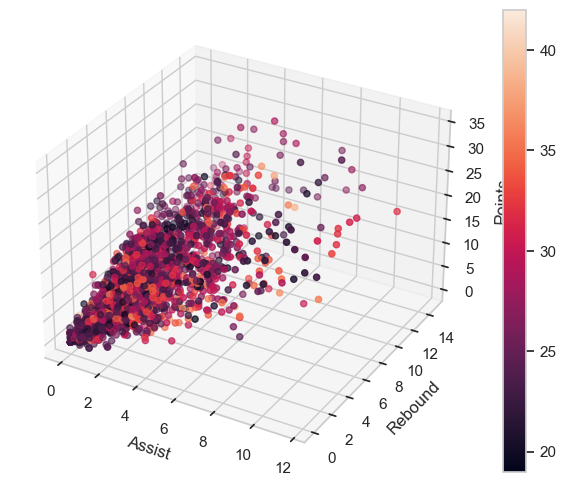

In [ ]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    final_df["AST"],
    final_df["TRB"],
    final_df["PTS"],
    c=final_df["Age"],  
)

ax.set_xlabel("Assist")
ax.set_ylabel("Rebound")

plt.colorbar(scatter)
plt.show()

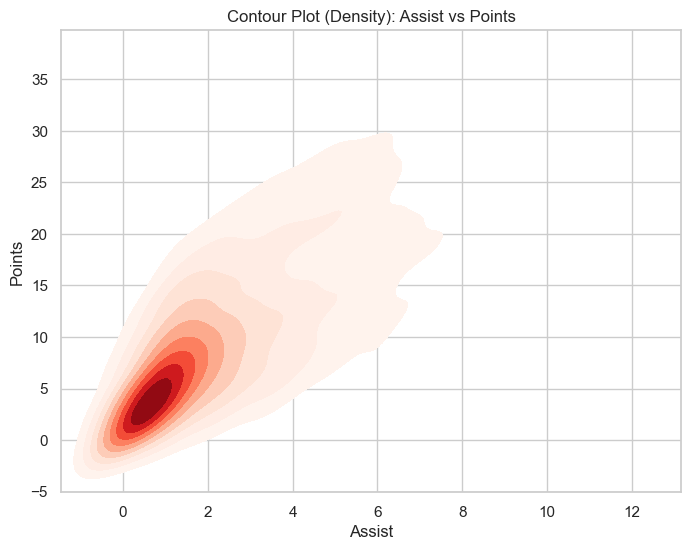

In [ ]:
plt.figure(figsize=(8,6))

sns.kdeplot(
    x=final_df["AST"],
    y=final_df["PTS"],
    fill=True,
    cmap="Reds",
    levels=10
)

plt.xlabel("Assist")
plt.ylabel("Points")
plt.title("Contour Plot (Density): Assist vs Points")

plt.show()

In [ ]:
final_df

,Player,Pos,Age,Team,G,PTS,AST,TRB,Season
0,Stephen Curry,PG,32.0,GSW,63.0,32.0,5.8,5.5,2021
1,Bradley Beal,SG,27.0,WAS,60.0,31.3,4.4,4.7,2021
2,Damian Lillard,PG,30.0,POR,67.0,28.8,7.5,4.2,2021
3,Joel Embiid,C,26.0,PHI,51.0,28.5,2.8,10.6,2021
4,Giannis Antetokounmpo,PF,26.0,MIL,61.0,28.1,5.9,11.0,2021
...,...,...,...,...,...,...,...,...,...
2930,Ron Harper Jr.,PF,23.0,TOR,1.0,0.0,1.0,0.0,2024
2931,Justin Jackson,SF,28.0,MIN,2.0,0.0,0.0,0.0,2024
2932,Dmytro Skapintsev,C,25.0,NYK,2.0,0.0,0.0,0.0,2024
2933,Javonte Smart,PG,24.0,PHI,1.0,0.0,0.0,0.0,2024


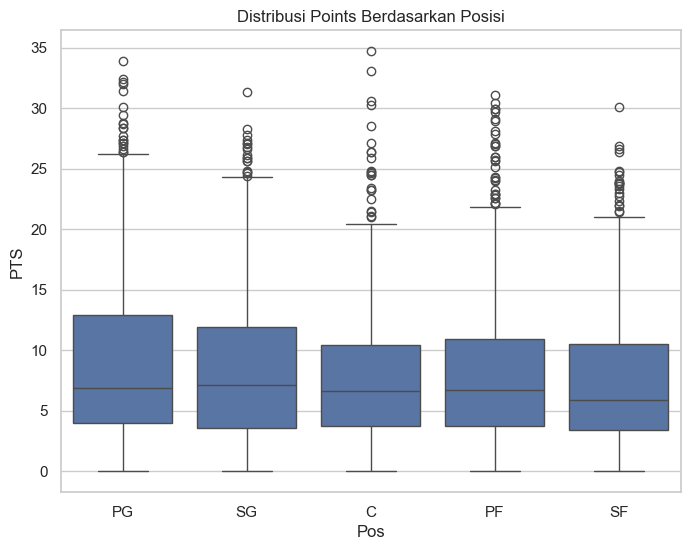

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.boxplot(
    x="Pos",
    y="PTS",
    data=final_df
)

plt.title("Distribusi Points Berdasarkan Posisi")
plt.show()

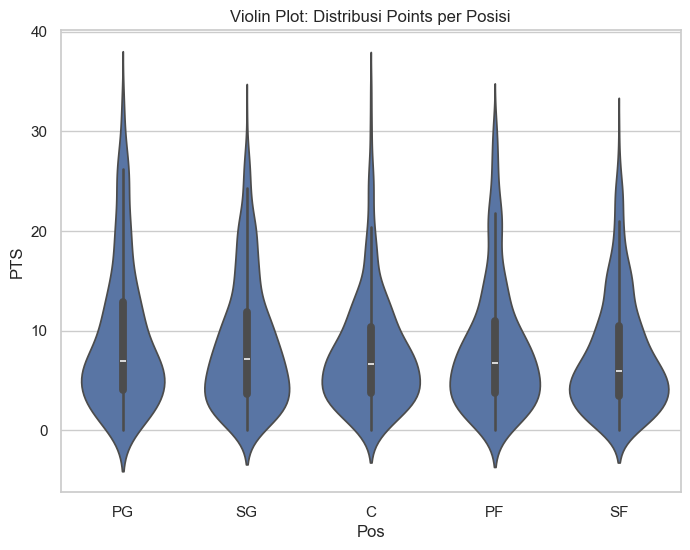

In [ ]:
# Violin Plot
plt.figure(figsize=(8,6))

sns.violinplot(
    x="Pos",
    y="PTS",
    data=final_df
)

plt.title("Violin Plot: Distribusi Points per Posisi")
plt.show()

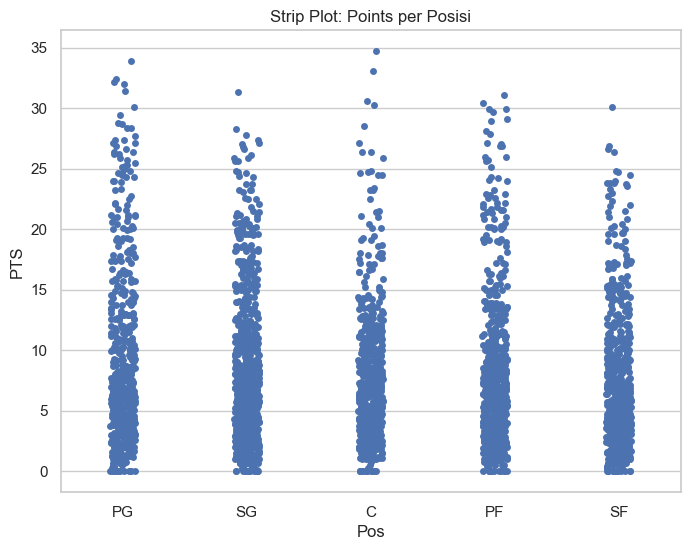

In [ ]:
# Strip plot
plt.figure(figsize=(8,6))

sns.stripplot(
    x="Pos",
    y="PTS",
    data=final_df,
    jitter=True
)

plt.title("Strip Plot: Points per Posisi")
plt.show()

<Figure size 800x600 with 0 Axes>

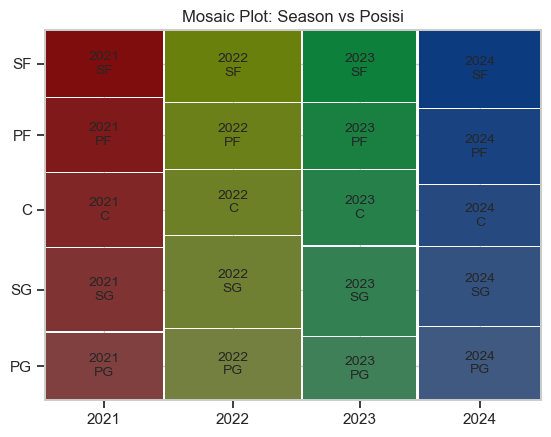

In [ ]:
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

mosaic(final_df, ["Season", "Pos"])

plt.title("Mosaic Plot: Season vs Posisi")
plt.show()

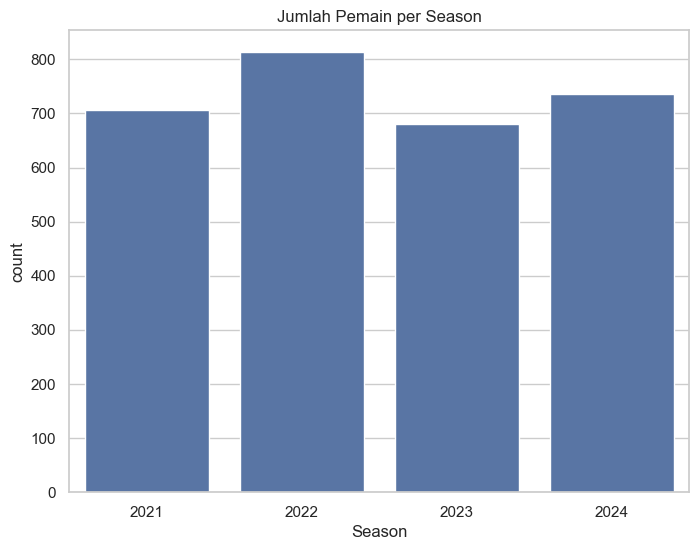

In [ ]:
plt.figure(figsize=(8,6))

sns.countplot(
    x="Season",
    data=final_df
)

plt.title("Jumlah Pemain per Season")
plt.show()

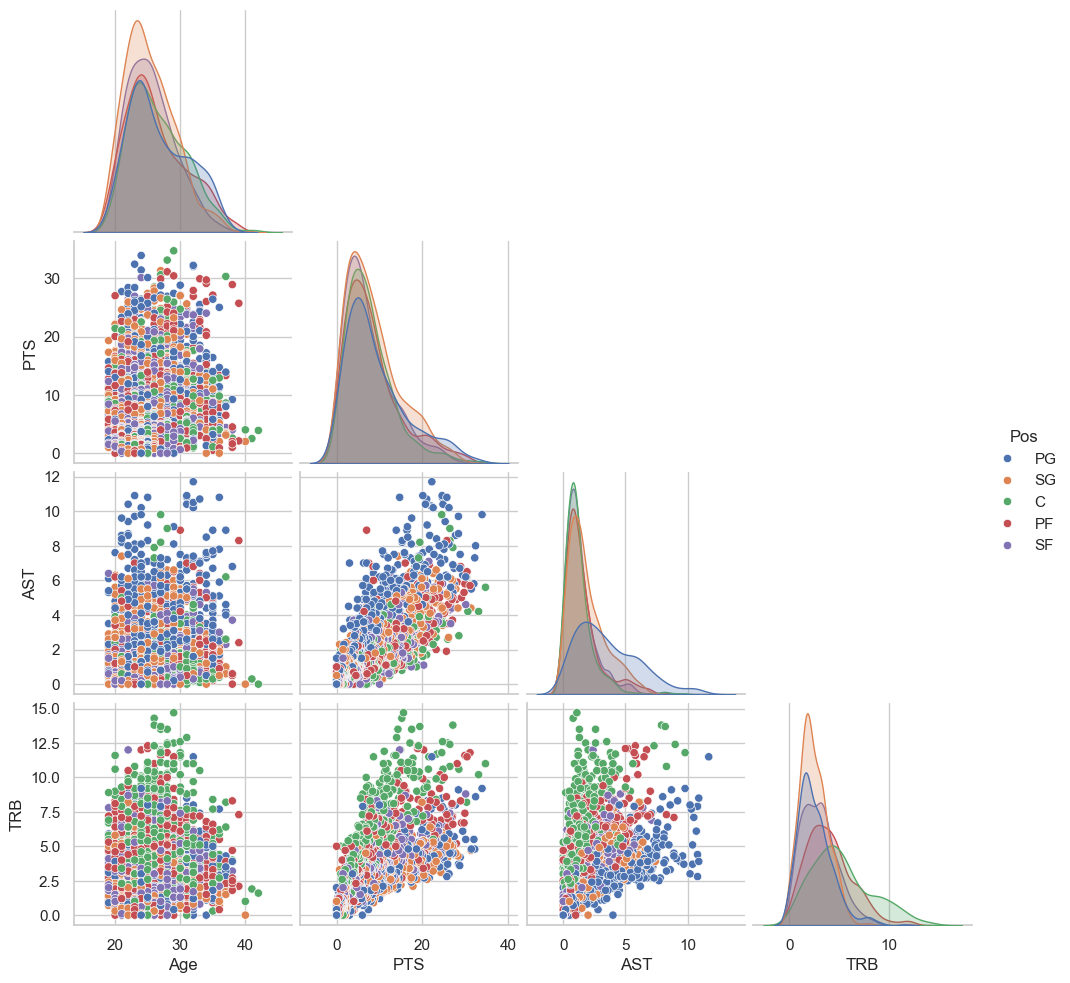

In [ ]:
sns.pairplot(
    final_df[["Age", "PTS", "AST", "TRB", "Pos"]],
    hue="Pos",
    corner=True
)

plt.show()


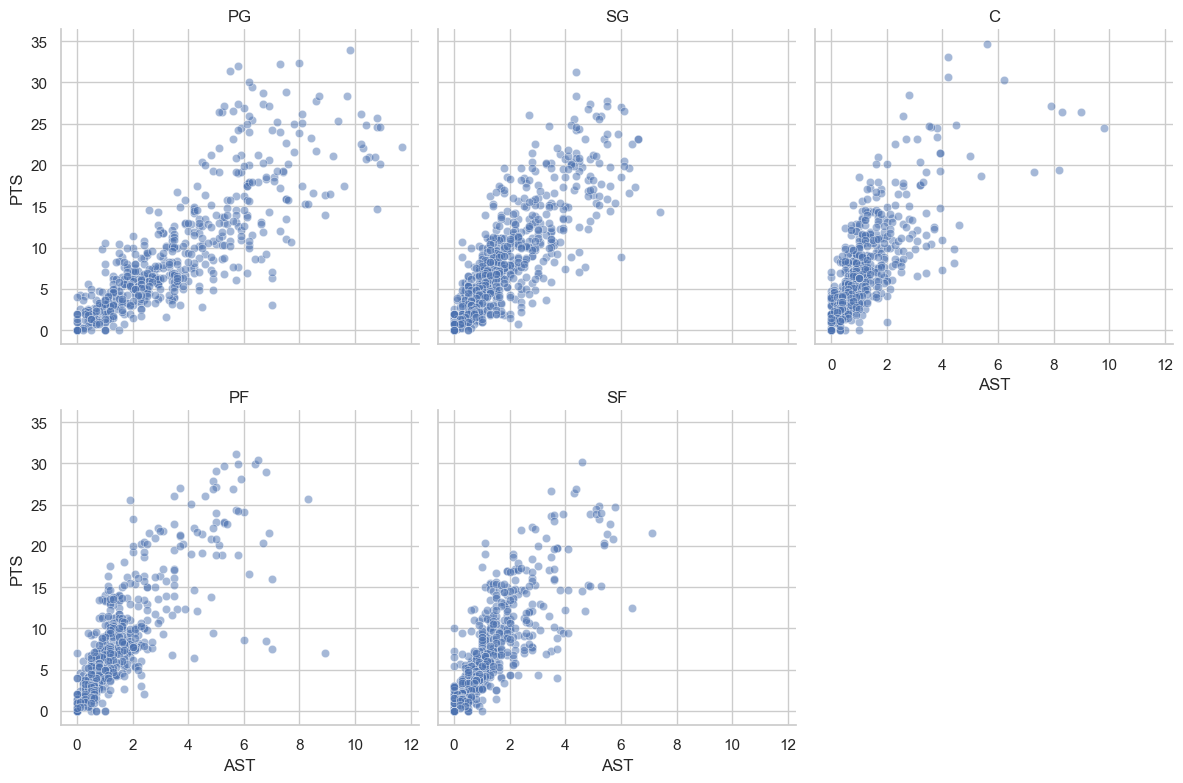

In [ ]:
g = sns.FacetGrid(final_df, col="Pos", col_wrap=3, height=4)
g.map_dataframe(sns.scatterplot, x="AST", y="PTS", alpha=0.5)

g.set_titles("{col_name}")
plt.show()

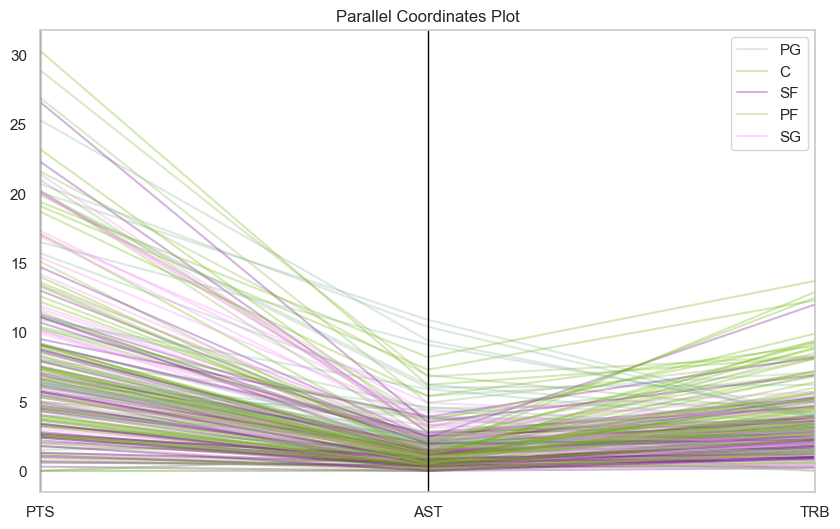

In [ ]:
from pandas.plotting import parallel_coordinates
import matplotlib.pyplot as plt

# Ambil subset kecil supaya tidak terlalu padat
sample_df = final_df.sample(200)

plt.figure(figsize=(10,6))

parallel_coordinates(
    sample_df[["Pos", "PTS", "AST", "TRB"]],
    class_column="Pos",
    alpha=0.3
)

plt.title("Parallel Coordinates Plot")
plt.show()

In [ ]:
final_df.head(50)

,Player,Pos,Age,Team,G,PTS,AST,TRB,Season
0,Stephen Curry,PG,32.0,GSW,63.0,32.0,5.8,5.5,2021
1,Bradley Beal,SG,27.0,WAS,60.0,31.3,4.4,4.7,2021
2,Damian Lillard,PG,30.0,POR,67.0,28.8,7.5,4.2,2021
3,Joel Embiid,C,26.0,PHI,51.0,28.5,2.8,10.6,2021
4,Giannis Antetokounmpo,PF,26.0,MIL,61.0,28.1,5.9,11.0,2021
5,Luka Dončić,PG,21.0,DAL,66.0,27.7,8.6,8.0,2021
6,Zach LaVine,SG,25.0,CHI,58.0,27.4,4.9,5.0,2021
7,Zion Williamson,PF,20.0,NOP,61.0,27.0,3.7,7.2,2021
8,Kevin Durant,PF,32.0,BRK,35.0,26.9,5.6,7.1,2021
9,Kyrie Irving,PG,28.0,BRK,54.0,26.9,6.0,4.8,2021


# Data yang di Presentasikan

In [ ]:
year = 2024
url = f"https://www.basketball-reference.com/leagues/NBA_{year}.html"

tables = pd.read_html(url)

# Biasanya table ke-0 atau ke-1 adalah standings
for i, table in enumerate(tables):
    print(i)
    print(table.head())

0
     Eastern Conference   W   L   W/L%    GB   PS/G   PA/G    SRS
0       Boston Celtics*  64  18  0.780     —  120.6  109.2  10.75
1      New York Knicks*  50  32  0.610  14.0  112.8  108.2   4.36
2      Milwaukee Bucks*  49  33  0.598  15.0  119.0  116.4   2.44
3  Cleveland Cavaliers*  48  34  0.585  16.0  112.6  110.2   1.98
4        Orlando Magic*  47  35  0.573  17.0  110.5  108.4   1.48
1
        Western Conference   W   L   W/L%   GB   PS/G   PA/G   SRS
0   Oklahoma City Thunder*  57  25  0.695    —  120.1  112.7  7.36
1          Denver Nuggets*  57  25  0.695    —  114.9  109.6  5.23
2  Minnesota Timberwolves*  56  26  0.683  1.0  113.0  106.5  6.39
3    Los Angeles Clippers*  51  31  0.622  6.0  115.6  112.3  3.41
4        Dallas Mavericks*  50  32  0.610  7.0  117.9  115.6  2.30
2
    Eastern Conference                  W                  L  \
0    Atlantic Division  Atlantic Division  Atlantic Division   
1      Boston Celtics*                 64                 18   
2   

In [ ]:
years = [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
all_data = []

for year in years:
    print(f"Scraping {year}...")
    
    url = f"https://www.basketball-reference.com/leagues/NBA_{year}.html"
    tables = pd.read_html(url)
    
    east = tables[0]
    west = tables[1]
    
    standings = pd.concat([east, west])
    
    # Hapus header ulang
    standings = standings[standings.iloc[:,0] != standings.columns[0]]
    
    # Ambil kolom berdasarkan posisi index (lebih aman)
    temp = standings.iloc[:, [0,1,2,5,6]].copy()
    temp.columns = ["Team", "Wins", "Losses", "Off_PTS", "Def_PTS"]
    
    # Pastikan string
    temp["Team"] = temp["Team"].astype(str)
    
    # Buat label playoff
    temp["Playoff"] = temp["Team"].apply(lambda x: 1 if "*" in x else 0)
    temp["Team"] = temp["Team"].str.replace("*", "", regex=False)
    
    # Tambahkan season
    temp["Season"] = year
    
    all_data.append(temp)

team_df = pd.concat(all_data, ignore_index=True)

print("Total data:", team_df.shape)
team_df.head(50)

Scraping 2019...


NameError: name 'pd' is not defined

In [ ]:
team_df.info()

,Team,Wins,Losses,Off_PTS,Def_PTS,Playoff,Season
160,Brooklyn Nets,32,50,110.4,113.3,0,2024
161,Toronto Raptors,25,57,112.4,118.8,0,2024
162,Charlotte Hornets,21,61,106.6,116.8,0,2024
163,Washington Wizards,15,67,113.7,123.0,0,2024
164,Detroit Pistons,14,68,109.9,119.0,0,2024
165,nan,57,25,120.1,112.7,0,2024
166,nan,57,25,114.9,109.6,0,2024
167,nan,56,26,113.0,106.5,0,2024
168,nan,51,31,115.6,112.3,0,2024
169,nan,50,32,117.9,115.6,0,2024


In [ ]:
team_df["Off_PTS"] = pd.to_numeric(team_df["Off_PTS"])
team_df["Def_PTS"] = pd.to_numeric(team_df["Def_PTS"])

In [ ]:
team_df["Def_Index"] = -team_df["Def_PTS"]
team_df["Off_Index"] = team_df["Off_PTS"]

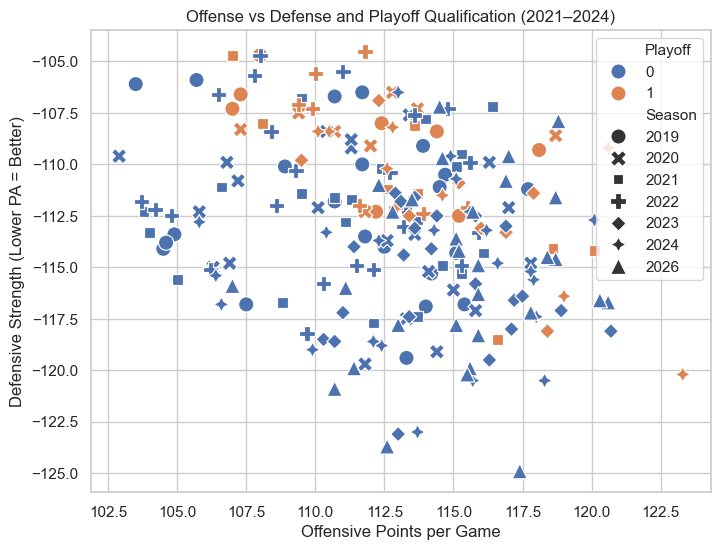

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=team_df,
    x="Off_Index",
    y="Def_Index",
    hue="Playoff",
    style="Season",
    s=120
)

plt.title("Offense vs Defense and Playoff Qualification (2021–2024)")
plt.xlabel("Offensive Points per Game")
plt.ylabel("Defensive Strength (Lower PA = Better)")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = team_df[["Off_Index", "Def_Index"]]
y = team_df["Playoff"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))
print("\nKoefisien:")
print("Offense:", model.coef_[0][0])
print("Defense:", model.coef_[0][1])

y_pred = model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7358490566037735

Koefisien:
Offense: 0.1697956524304679
Defense: 0.3768447326252947

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84        42
           1       0.33      0.27      0.30        11

    accuracy                           0.74        53
   macro avg       0.58      0.56      0.57        53
weighted avg       0.72      0.74      0.73        53



In [ ]:
print(team_df[team_df["Team"].isna()])

Empty DataFrame
Columns: [Team, Wins, Losses, Off_PTS, Def_PTS, Playoff, Season, Def_Index, Off_Index]
Index: []


In [ ]:
team_df = team_df[team_df["Team"].notna()]

In [ ]:
team_df = team_df.dropna(subset=["Team"])

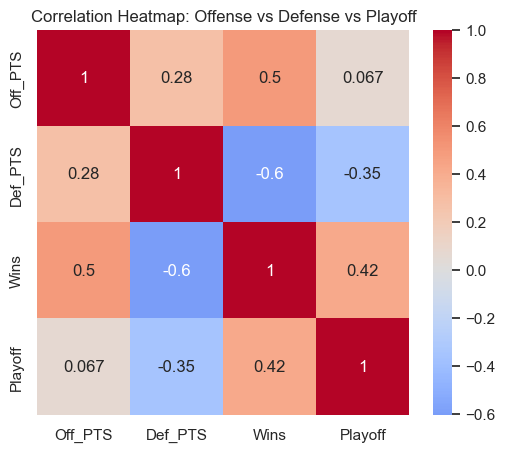

In [ ]:
corr = team_df[[
    "Off_PTS",
    "Def_PTS",
    "Wins",
    "Playoff"
]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)

plt.title("Correlation Heatmap: Offense vs Defense vs Playoff")
plt.show()

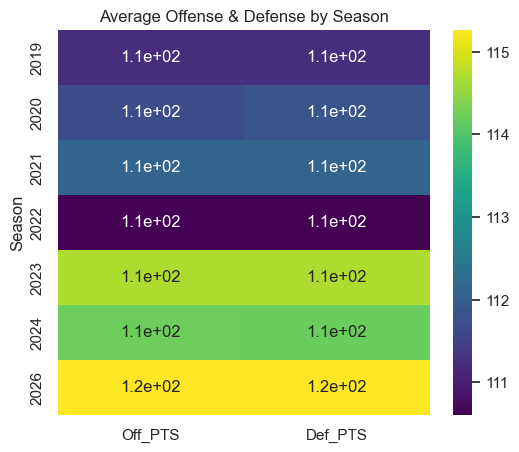

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(
    team_df.groupby("Season")[["Off_PTS","Def_PTS"]].mean(),
    annot=True,
    cmap="viridis"
)
plt.title("Average Offense & Defense by Season")
plt.show()

# Data cleaning

In [ ]:
print("Jumlah data sebelum cleaning:", team_df.shape)

Jumlah data sebelum cleaning: (210, 9)


In [ ]:
print(team_df.isna().sum())

Team         0
Wins         0
Losses       0
Off_PTS      0
Def_PTS      0
Playoff      0
Season       0
Def_Index    0
Off_Index    0
dtype: int64


In [ ]:
print("Total NaN:", team_df.isna().sum().sum())

Total NaN: 0


In [ ]:
team_df_clean = team_df.dropna()

In [ ]:
team_df_clean = team_df.dropna(subset=["Team"])

In [ ]:
team_df_clean = team_df.dropna().reset_index(drop=True)

In [ ]:
team_df_clean

,Team,Wins,Losses,Off_PTS,Def_PTS,Playoff,Season,Def_Index,Off_Index
0,Milwaukee Bucks,60,22,118.1,109.3,1,2019,-109.3,118.1
1,Toronto Raptors,58,24,114.4,108.4,1,2019,-108.4,114.4
2,Philadelphia 76ers,51,31,115.2,112.5,1,2019,-112.5,115.2
3,Boston Celtics,49,33,112.4,108.0,1,2019,-108.0,112.4
4,Indiana Pacers,48,34,108.0,104.7,1,2019,-104.7,108.0
...,...,...,...,...,...,...,...,...,...
205,nan,23,41,115.9,118.3,0,2026,-118.3,115.9
206,nan,21,44,113.0,117.8,0,2026,-117.8,113.0
207,nan,21,45,115.5,120.2,0,2026,-120.2,115.5
208,nan,20,45,117.4,124.9,0,2026,-124.9,117.4


In [ ]:
print(team_df[team_df["Team"].isna()])

Empty DataFrame
Columns: [Team, Wins, Losses, Off_PTS, Def_PTS, Playoff, Season, Def_Index, Off_Index]
Index: []


In [ ]:
team_df_clean = team_df[team_df["Team"].notna()].copy()

In [ ]:
team_df_clean

,Team,Wins,Losses,Off_PTS,Def_PTS,Playoff,Season,Def_Index,Off_Index
0,Milwaukee Bucks,60,22,118.1,109.3,1,2019,-109.3,118.1
1,Toronto Raptors,58,24,114.4,108.4,1,2019,-108.4,114.4
2,Philadelphia 76ers,51,31,115.2,112.5,1,2019,-112.5,115.2
3,Boston Celtics,49,33,112.4,108.0,1,2019,-108.0,112.4
4,Indiana Pacers,48,34,108.0,104.7,1,2019,-104.7,108.0
...,...,...,...,...,...,...,...,...,...
205,nan,23,41,115.9,118.3,0,2026,-118.3,115.9
206,nan,21,44,113.0,117.8,0,2026,-117.8,113.0
207,nan,21,45,115.5,120.2,0,2026,-120.2,115.5
208,nan,20,45,117.4,124.9,0,2026,-124.9,117.4


In [ ]:
print(team_df["Team"].unique())

['Milwaukee Bucks' 'Toronto Raptors' 'Philadelphia 76ers' 'Boston Celtics'
 'Indiana Pacers' 'Brooklyn Nets' 'Orlando Magic' 'Detroit Pistons'
 'Charlotte Hornets' 'Miami Heat' 'Washington Wizards' 'Atlanta Hawks'
 'Chicago Bulls' 'Cleveland Cavaliers' 'New York Knicks' 'nan'
 'Detroit Pistons\xa0(1)' 'Boston Celtics\xa0(2)' 'New York Knicks\xa0(3)'
 'Cleveland Cavaliers\xa0(4)' 'Toronto Raptors\xa0(5)' 'Miami Heat\xa0(6)'
 'Orlando Magic\xa0(7)' 'Philadelphia 76ers\xa0(8)' 'Atlanta Hawks\xa0(9)'
 'Charlotte Hornets\xa0(10)' 'Milwaukee Bucks\xa0(11)'
 'Chicago Bulls\xa0(12)' 'Brooklyn Nets\xa0(13)'
 'Washington Wizards\xa0(14)' 'Indiana Pacers\xa0(15)']


In [ ]:
team_df_clean = team_df[
    (team_df["Team"].notna()) &
    (team_df["Team"].str.lower() != "nan")
].copy()

team_df_clean.reset_index(drop=True, inplace=True)

In [ ]:
print("Jumlah NaN asli:", team_df_clean["Team"].isna().sum())
print("Jumlah string 'nan':", (team_df_clean["Team"].str.lower() == "nan").sum())

Jumlah NaN asli: 0
Jumlah string 'nan': 0


In [ ]:
team_df_clean.head(50)

,Team,Wins,Losses,Off_PTS,Def_PTS,Playoff,Season,Def_Index,Off_Index
0,Milwaukee Bucks,60,22,118.1,109.3,1,2019,-109.3,118.1
1,Toronto Raptors,58,24,114.4,108.4,1,2019,-108.4,114.4
2,Philadelphia 76ers,51,31,115.2,112.5,1,2019,-112.5,115.2
3,Boston Celtics,49,33,112.4,108.0,1,2019,-108.0,112.4
4,Indiana Pacers,48,34,108.0,104.7,1,2019,-104.7,108.0
5,Brooklyn Nets,42,40,112.2,112.3,1,2019,-112.3,112.2
6,Orlando Magic,42,40,107.3,106.6,1,2019,-106.6,107.3
7,Detroit Pistons,41,41,107.0,107.3,1,2019,-107.3,107.0
8,Charlotte Hornets,39,43,110.7,111.8,0,2019,-111.8,110.7
9,Miami Heat,39,43,105.7,105.9,0,2019,-105.9,105.7


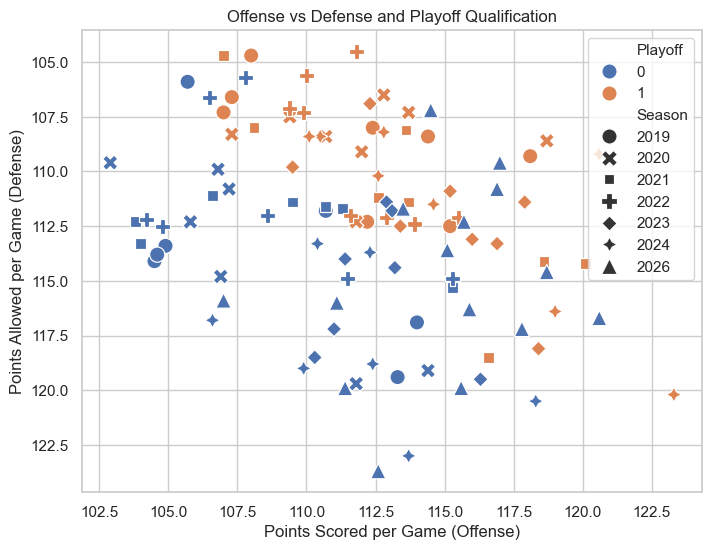

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=team_df_clean,
    x="Off_PTS",
    y="Def_PTS",
    hue="Playoff",
    style="Season",
    s=120
)

plt.title("Offense vs Defense and Playoff Qualification")
plt.xlabel("Points Scored per Game (Offense)")
plt.ylabel("Points Allowed per Game (Defense)")
plt.gca().invert_yaxis()  # Defense makin kecil makin bagus
plt.show()

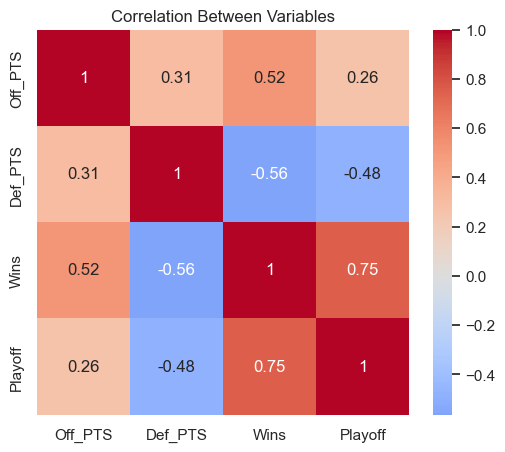

In [ ]:
corr = team_df_clean[[
    "Off_PTS",
    "Def_PTS",
    "Wins",
    "Playoff"
]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)

plt.title("Correlation Between Variables")
plt.show()

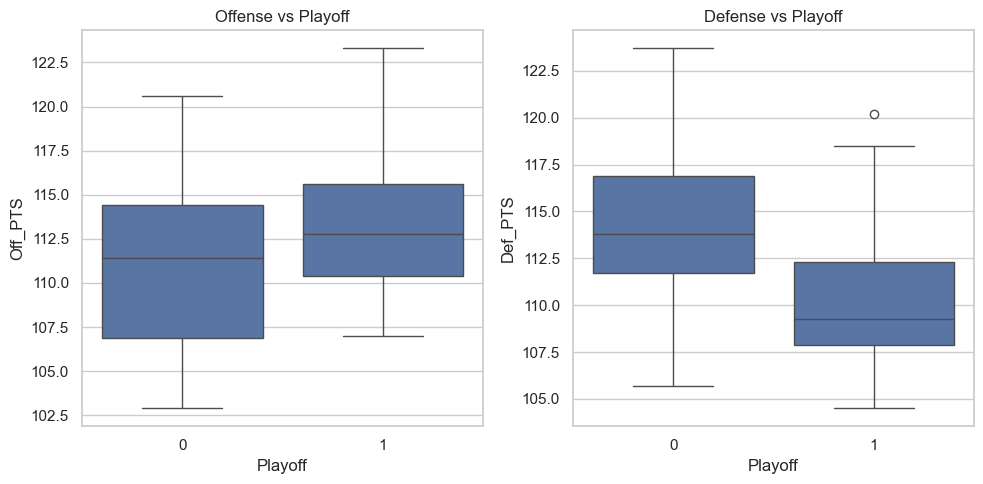

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.boxplot(x="Playoff", y="Off_PTS", data=team_df_clean)
plt.title("Offense vs Playoff")

plt.subplot(1,2,2)
sns.boxplot(x="Playoff", y="Def_PTS", data=team_df_clean)
plt.title("Defense vs Playoff")

plt.tight_layout()
plt.show()

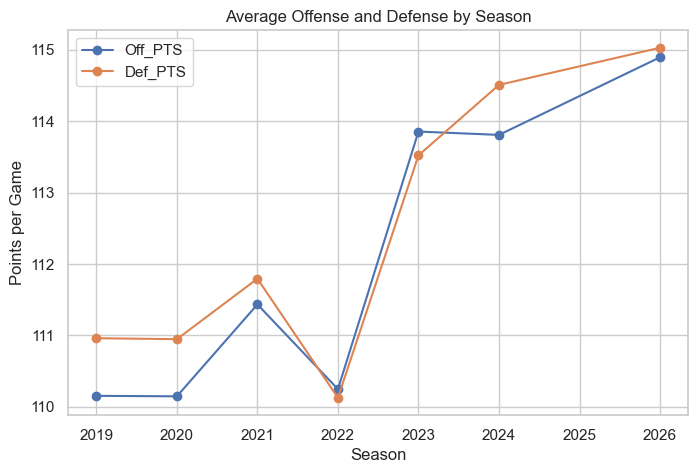

In [ ]:
avg = team_df_clean.groupby("Season")[["Off_PTS","Def_PTS"]].mean()

avg.plot(marker="o", figsize=(8,5))
plt.title("Average Offense and Defense by Season")
plt.ylabel("Points per Game")
plt.show()

In [ ]:
team_df_clean[team_df_clean["Season"] == 2023][
    ["Off_PTS", "Def_PTS", "Wins"]
].corr()

,Off_PTS,Def_PTS,Wins
Off_PTS,1.000000,0.160441,0.568158
Def_PTS,0.160441,1.000000,-0.667900
Wins,0.568158,-0.667900,1.000000


In [ ]:
team_df_clean[team_df_clean["Season"] == 2022][
    ["Off_PTS", "Def_PTS", "Wins"]
].corr()

,Off_PTS,Def_PTS,Wins
Off_PTS,1.000000,0.277295,0.584872
Def_PTS,0.277295,1.000000,-0.536796
Wins,0.584872,-0.536796,1.000000


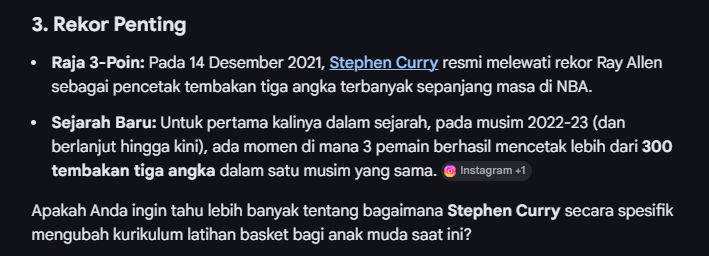

In [ ]:
from IPython.display import Image, display

display(Image(filename="C:\\Users\\hafid\\Documents\\Kuliah\\Coding\\sains-data\\Screenshot 2026-02-28 145705.png"))

# Topik 2

In [ ]:
team_df_clean["Net_Rating"] = team_df_clean["Off_PTS"] - team_df_clean["Def_PTS"]

team_df_clean.head()

,Team,Wins,Losses,Off_PTS,Def_PTS,Playoff,Season,Def_Index,Off_Index,Net_Rating
0,Milwaukee Bucks,60,22,118.1,109.3,1,2019,-109.3,118.1,8.8
1,Toronto Raptors,58,24,114.4,108.4,1,2019,-108.4,114.4,6.0
2,Philadelphia 76ers,51,31,115.2,112.5,1,2019,-112.5,115.2,2.7
3,Boston Celtics,49,33,112.4,108.0,1,2019,-108.0,112.4,4.4
4,Indiana Pacers,48,34,108.0,104.7,1,2019,-104.7,108.0,3.3


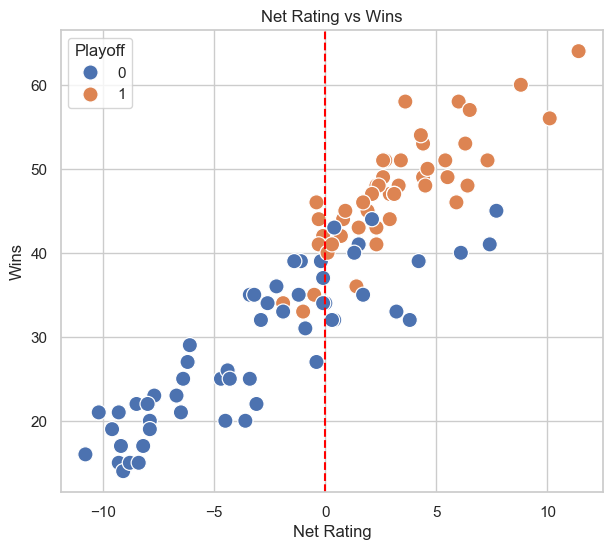

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

sns.scatterplot(
    data=team_df_clean,
    x="Net_Rating",
    y="Wins",
    hue="Playoff",
    s=120
)

plt.axvline(0, color='red', linestyle="--")

plt.title("Net Rating vs Wins")
plt.xlabel("Net Rating")
plt.ylabel("Wins")

plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [ ]:
X = team_df_clean[["Net_Rating"]]
y = team_df_clean["Playoff"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
team_df_clean.to_excel("nba_data.xlsx", index=False)

In [ ]:
print(team_df_clean.shape)

(105, 10)
